In [1]:
# Data processing
import pandas as pd
import xarray as xr
import numpy as np
import math

# Plotting 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# Stat and ML
from scipy import stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import chi2
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import detrend
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Personal library
from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents
from utils.granger_causality_test import test_granger_causality, test_granger_causality_non_parametric
from utils.xarray_numpy import xr2np, np2D_to_np3D
from utils.utils import generate_past_data, lag_analysis, plot_lag_results, compute_aic_bic, explained_variance_ratio_fast
from utils.plot_weights import *

np.random.seed(1234)

## Loading data

In [2]:
ndvi = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/X.tsv')
oscillation = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/Y.tsv')
mask = xr.open_dataset('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/NORTHERN_SOUTH_AMERICA/NDVI/na_mask.nc')
extent = [-83, -60, -14, 14]

# removing masked values
na_mask = mask['na_mask'].values 

# Preprocessing: Removing anomalies
seasonalities = ndvi.reshape(20, 23, -1).mean(axis=0)
ndvi_anomalies = ndvi.reshape(20, 23, -1) - seasonalities

# Preprocessing: Creating a 2D numpy array
anomalies = ndvi_anomalies.reshape(460, -1)
shape = na_mask.shape

## Data preprocessing

In [3]:
# Detrending
anomalies = detrend(anomalies, axis=0, type='linear')
oscillation = detrend(oscillation, axis=0, type='linear')

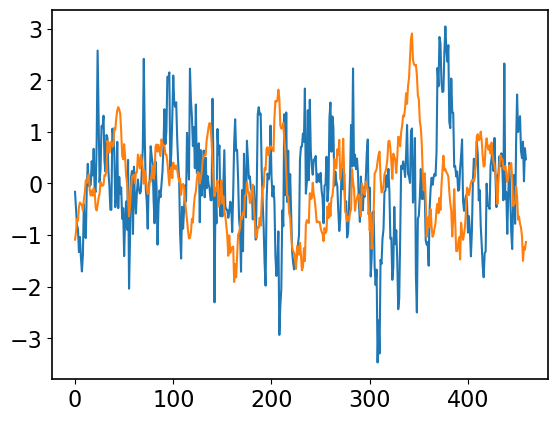

In [4]:
plt.plot(anomalies.mean(axis=1)/anomalies.mean(axis=1).std())
plt.plot(oscillation)

In [5]:
# Data splitting
train_ratio = 0.99
    
n = len(anomalies)
train_size = int(n * train_ratio)

anomalies_train = anomalies[:train_size, :]
anomalies_test  = anomalies[train_size:, :]

oscillation_train = oscillation[:train_size]
oscillation_test  = oscillation[train_size:]

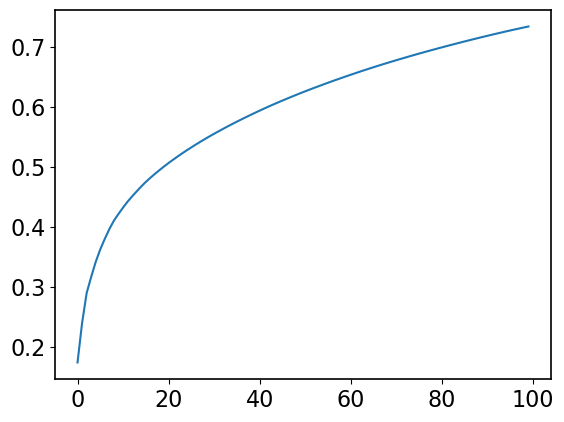

In [6]:
# Principal Component Analysis
ncp = 100
    
pca = PCA(n_components=ncp)
pca.fit(anomalies_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))


anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test = pca.transform(anomalies_test)

anomalies_pca = pca.transform(anomalies)

## Fitting Granger PCA
* Seting maxlag to *None* to that optimal lag is selected to maximise the *lag_criterion* score of a model predicting $Y$ from $X$ and $Y$'s pasts.
* Different algorithms are available: *diff_ratio* maximise the F-statistic, *ratio* maximise the likelihood ratio and *difference* maximise the RSS difference

In [7]:
def get_weights(anomalies_pca, anomalies, algo, idx=0):
    cp = algo.transform(anomalies_pca)
    if len(cp.shape)> 1:
        if cp.shape[1]>1:
            cp = cp[:, idx]
    lr = LinearRegression()
    lr.fit(anomalies, cp)
    return lr.coef_

In [13]:
lags = [1, 2]
mu_grid=np.logspace(-20, 0, 100, base=2)
alphas = np.logspace(-5, 20, 100) # Search space for ridge regression hyperparameter
EVRs_train, EVRs_test = [], []
F_stats_train, F_stats_test = [], []
FC_train, FC_test = [], []
SCORES = []

for lag in tqdm(lags):
    evrs_train = []
    Fs_train = []
    evrs_test = []
    Fs_test = []
    F_crit_train, F_crit_test = [], []
    scores = []
    for mu in mu_grid:
        gpca = GrangerPCA(maxlag=lag, method='diff_ratio',# maxlags=range(1, 5), lag_criterion='r2_median',  #Lag selection
                  model_res=RidgeCV(alphas=alphas), model_full=RidgeCV(alphas=alphas), alpha=1e-4, #Regression models and stabilisation
                  residuals_computation="block_cv", block_cv_n_blocks=3, # Scheme for computing residuals
                  mu=mu, mu_grid=mu_grid, test_level=1e-1) #Granger PCA regularisation
        gpca.fit(oscillation_train[:, None], anomalies_pca_train, plot_lag_analysis=False, verbose=False)
        cp_test_gpca = gpca.transform(anomalies_pca_test)
        cp_train_gpca = gpca.transform(anomalies_pca_train)
        
        weights_gpca_train = get_weights(anomalies_pca_train, anomalies_train, gpca, idx=0)
        weights_gpca_test = get_weights(anomalies_pca_test, anomalies_test, gpca, idx=0)

        results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=[lag], alpha=1e-4)
        F_test = results_gpca[results_gpca['lag'] == lag]['F_statistic'][0]
        F_critical_test = results_gpca[results_gpca['lag'] == lag]['F_critical'][0]


        results_gpca = test_granger_causality(oscillation_train[:, None], cp_train_gpca[:, 0], maxlag=[lag], alpha=1e-4)
        F_train = results_gpca[results_gpca['lag'] == lag]['F_statistic'][0]
        F_critical_train = results_gpca[results_gpca['lag'] == lag]['F_critical'][0]
        
        weights_gpca_train = np.ravel(weights_gpca_train)
        weights_gpca_test = np.ravel(weights_gpca_test)
        evr_train = explained_variance_ratio_fast(anomalies_test, weights_gpca_train)
        evr_test = explained_variance_ratio_fast(anomalies_test, weights_gpca_test)
        
        evrs_train.append(evr_train)
        Fs_train.append(F_train)
        
        evrs_test.append(evr_test)
        Fs_test.append(F_test)
        
        F_crit_train.append(F_critical_train)
        F_crit_test.append(F_critical_test)
        scores.append((mu, evr_train, F_train, F_critical_train))
        
    EVRs_train.append(evrs_train)
    EVRs_test.append(evrs_test)
    

    F_stats_train.append(Fs_train)
    F_stats_test.append(Fs_test)
    
    FC_train.append(F_crit_train)
    FC_test.append(F_crit_test)
    SCORES.append(scores)

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [04:04<04:04, 244.26s/it]/home/homer/Documents/Research/Projects/granger_pca_teleconnection/utils/granger_causality_test.py:116: RuntimeWarning: invalid value encountered in scalar divide
  F_stat = (df2 / df1) * (rss_res - rss_full) / rss_full
/home/homer/Documents/Research/Projects/granger_pca_teleconnection/utils/granger_causality_test.py:116: RuntimeWarning: divide by zero encountered in scalar divide
  F_stat = (df2 / df1) * (rss_res - rss_full) / rss_full
/home/homer/Documents/Research/Projects/granger_pca_teleconnection/utils/granger_causality_test.py:116: RuntimeWarning: divide by zero encountered in scalar divide
  F_stat = (df2 / df1) * (rss_res - rss_full) / rss_full
/home/homer/Documents/Research/Projects/granger_pca_teleconnection/utils/granger_causality_test.py:116: RuntimeWarning: invalid value encountered in scalar divide
  F_stat = (df2 / df1) * (rss_res - rss_full) / rss_full
/home/homer/Documents/Research/Projects/granger_pca_teleconnection/utils

In [14]:
def find_optimal_idx(scores):
    scores = pd.DataFrame(
                    scores, columns=["mu", "EVR", "F_stat", "F_crit"]
                )
    admissible = scores[scores["F_stat"] > scores["F_crit"]]

    if len(admissible) > 0:
        mu_star = admissible.iloc[admissible["EVR"].argmax()]["mu"]
    else:
        mu_star = scores.iloc[scores["F_stat"].argmax()]["mu"]

    idx = scores[scores['mu']==mu_star].index[0]
    return idx

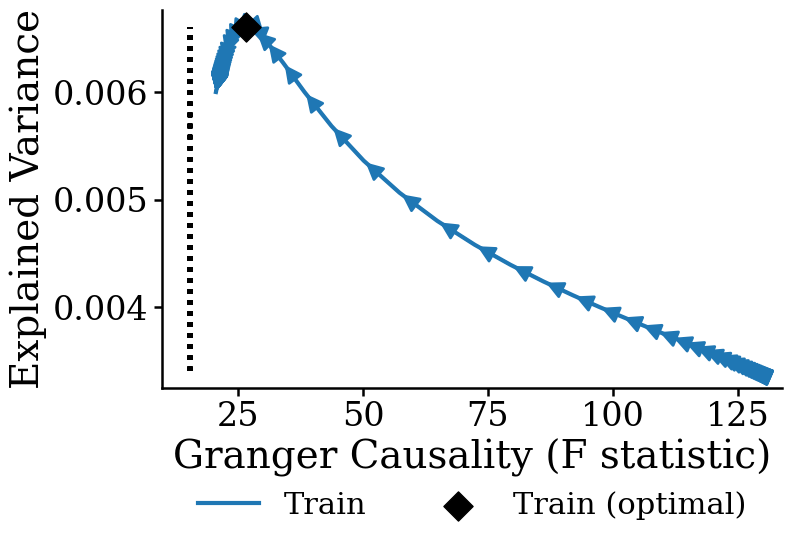

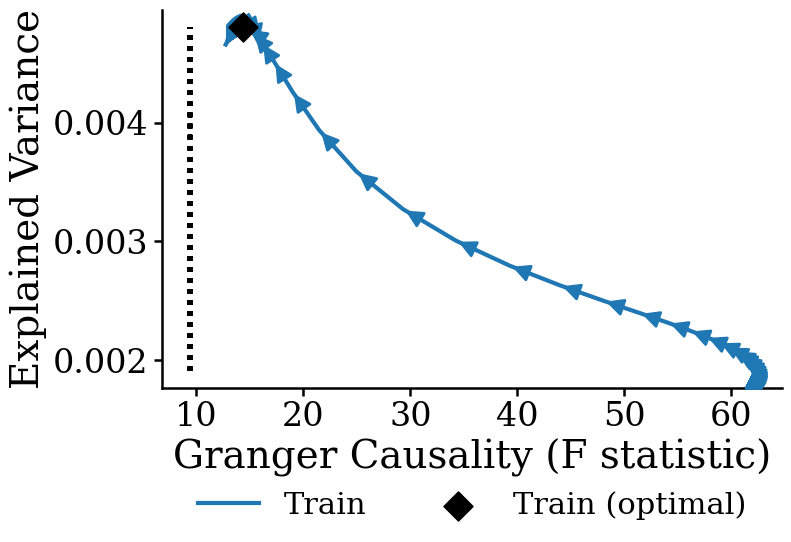

In [15]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ======================================================
# Publication-quality matplotlib settings
# ======================================================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 26,
    "axes.labelsize": 28,
    "axes.titlesize": 28,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 22,
    "axes.linewidth": 1.8,
    "lines.linewidth": 3,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ======================================================
# Ensure output directory exists
# ======================================================
os.makedirs("figures", exist_ok=True)

# ======================================================
# Plot loop
# ======================================================
for lag_idx, lag in enumerate(lags):

    fig, ax = plt.subplots(figsize=(8, 6))

    # ======================
    # TRAIN (blue)
    # ======================
    x_tr = F_stats_train[lag_idx]
    y_tr = EVRs_train[lag_idx]

    line_tr, = ax.plot(
        x_tr,
        y_tr,
        color='tab:blue',
        label='Train'
    )

    for i in range(len(x_tr) - 1):
        ax.annotate(
            '',
            xy=(x_tr[i+1], y_tr[i+1]),
            xytext=(x_tr[i], y_tr[i]),
            arrowprops=dict(
                arrowstyle='-|>',
                lw=2,
                color=line_tr.get_color(),
            )
        )

    # ======================
    # TEST (orange)
    # ======================
    x_te = F_stats_test[lag_idx]
    y_te = EVRs_test[lag_idx]

    # line_te, = ax.plot(
    #     x_te,
    #     y_te,
    #     color='tab:orange',
    #     label='Test'
    # )

    # for i in range(len(x_te) - 1):
    #     ax.annotate(
    #         '',
    #         xy=(x_te[i+1], y_te[i+1]),
    #         xytext=(x_te[i], y_te[i]),
    #         arrowprops=dict(
    #             arrowstyle='-|>',
    #             lw=2,
    #             color=line_te.get_color(),
    #         )
    #     )

    # ======================
    # OPTIMAL POINT (black markers)
    # ======================
    scores = SCORES[lag_idx]
    idx = find_optimal_idx(scores)
    

    ax.scatter(
        x_tr[idx],
        y_tr[idx],
        s=220,
        marker='D',      # diamond
        color='black',
        zorder=6,
        label='Train (optimal)'
    )

    # ax.scatter(
    #     x_te[idx],
    #     y_te[idx],
    #     s=220,
    #     marker='o',      # circle
    #     color='black',
    #     zorder=6,
    #     label='Test (optimal)'
    # )
    
    F_crit_train = np.array(FC_train[lag_idx])
    ymin, ymax = np.min(np.stack((y_tr))), np.max(np.stack((y_tr)))
    plt.vlines(x=F_crit_train, ymin=ymin, ymax=ymax, linestyles=':', color='black')

    # ======================
    # Labels
    # ======================
    ax.set_xlabel('Granger Causality (F statistic)')
    ax.set_ylabel('Explained Variance')

    # Clean scientific look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out')

    # ======================
    # Bottom legend
    # ======================
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),
        ncol=2,
        frameon=False
    )

    # Adjust layout to accommodate legend
    fig.subplots_adjust(bottom=0.25)

    # ======================
    # Save figure
    # ======================
    fig.savefig(
        f'figures/Trade-off-EVR-GC-npc{ncp}-lag{lag}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()